In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
RAW_DIR = "../data/wisdm-dataset/raw"
SUBJECTS = range(1600, 1651)  # 51 subjects

SENSORS = [("phone", "accel"), ("phone", "gyro"), ("watch", "accel"), ("watch", "gyro")]

ACTIVITIES = {
    "A": "Walking",
    "B": "Jogging",
    "C": "Stairs",
    "D": "Sitting",
    "E": "Standing",
    "F": "Typing",
    "G": "Brushing Teeth",
    "H": "Eating Soup",
    "I": "Eating Chips",
    "J": "Eating Pasta",
    "K": "Drinking from Cup",
    "L": "Eating Sandwich",
    "M": "Kicking (Soccer Ball)",
    "O": "Playing Catch w/Tennis Ball",
    "P": "Dribbling (Basketball)",
    "Q": "Writing",
    "R": "Clapping",
    "S": "Folding Clothes",
}

In [6]:
def get_sensor_data(filepath):
    df = pd.read_csv(
        filepath,
        header=None,
        names=["subject_id", "activity", "timeStamp", "x", "y", "z"],
    )

    df.iloc[:, -1] = df.iloc[:, -1].str.rstrip(";")

    df = df.astype({"z": float})

    df["timeStamp"] = pd.to_datetime(df["timeStamp"], unit="ns")
    df.drop(columns="subject_id", inplace=True)

    return df

In [7]:
def get_subject_data(subject_id, log):

    dfs: list[pd.DataFrame] = []

    for device, sensor in SENSORS:

        df = get_sensor_data(
            f"{RAW_DIR}/{device}/{sensor}/data_{subject_id}_{sensor}_{device}.txt"
        )

        df["device"] = device

        df = df.rename(
            columns={
                "x": f"x_{sensor}",
                "y": f"y_{sensor}",
                "z": f"z_{sensor}",
            }
        )

        dfs.append(df)

    for df in dfs:
        df.sort_values(by="timeStamp", inplace=True)

    merged_phone = pd.merge_asof(
        dfs[0] if dfs[0].shape[0] < dfs[1].shape[0] else dfs[1],
        dfs[0] if dfs[0].shape[0] >= dfs[1].shape[0] else dfs[1],
        on="timeStamp",
        by=["activity", "device"],
        direction="nearest",
        tolerance=pd.Timedelta("100ms"),
    )

    if log:
        print(f"{merged_phone.shape[0]} rows of phone data")

    # return merged_phone

    merged_watch = pd.merge_asof(
        dfs[2] if dfs[2].shape[0] < dfs[3].shape[0] else dfs[3],
        dfs[2] if dfs[2].shape[0] >= dfs[3].shape[0] else dfs[3],
        on="timeStamp",
        by=["activity", "device"],
        direction="nearest",
        tolerance=pd.Timedelta("100ms"),
    )

    if log:
        print(f"{merged_watch.shape[0]} rows of phone data")

    merged = pd.concat([merged_phone, merged_watch])

    merged = merged.iloc[:, [5, 0, 1, 2, 3, 4, 6, 7, 8]]

    merged["activity"] = merged["activity"].astype("category")
    merged["device"] = merged["device"].astype("category")

    return merged.sort_values(by=["device", "activity", "timeStamp"])

In [5]:
df = get_subject_data(1600, True)

df.info()

64247 rows of phone data
65435 rows of phone data
<class 'pandas.DataFrame'>
Index: 129682 entries, 39263 to 18590
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     129682 non-null  category      
 1   activity   129682 non-null  category      
 2   timeStamp  129682 non-null  datetime64[ns]
 3   x_gyro     129682 non-null  float64       
 4   y_gyro     129682 non-null  float64       
 5   z_gyro     129682 non-null  float64       
 6   x_accel    129682 non-null  float64       
 7   y_accel    129682 non-null  float64       
 8   z_accel    129682 non-null  float64       
dtypes: category(2), datetime64[ns](1), float64(6)
memory usage: 8.2 MB


In [6]:
def load_all_data():

    merged = pd.DataFrame()

    for subject_id in SUBJECTS:

        print(f"loading {subject_id} data...")

        if subject_id == SUBJECTS.start:
            merged = get_subject_data(subject_id, False)
            merged["subject_id"] = np.ones(merged.shape[0], dtype=int) * subject_id
            continue

        other = get_subject_data(subject_id, False)
        other["subject_id"] = np.ones(other.shape[0], dtype=int) * subject_id
        merged = pd.concat([merged, other])

    merged["subject_id"] = merged["subject_id"].astype("category")
    merged["activity"] = merged["activity"].astype("category")

    merged = merged.reindex(
        columns=[
            "subject_id",
            "device",
            "activity",
            "timeStamp",
            "x_accel",
            "y_accel",
            "z_accel",
            "x_gyro",
            "y_gyro",
            "z_gyro",
        ]
    )

    return merged

In [7]:
df = load_all_data()

loading 1600 data...
loading 1601 data...
loading 1602 data...
loading 1603 data...
loading 1604 data...
loading 1605 data...
loading 1606 data...
loading 1607 data...
loading 1608 data...
loading 1609 data...
loading 1610 data...
loading 1611 data...
loading 1612 data...
loading 1613 data...
loading 1614 data...
loading 1615 data...
loading 1616 data...
loading 1617 data...
loading 1618 data...
loading 1619 data...
loading 1620 data...
loading 1621 data...
loading 1622 data...
loading 1623 data...
loading 1624 data...
loading 1625 data...
loading 1626 data...
loading 1627 data...
loading 1628 data...
loading 1629 data...
loading 1630 data...
loading 1631 data...
loading 1632 data...
loading 1633 data...
loading 1634 data...
loading 1635 data...
loading 1636 data...
loading 1637 data...
loading 1638 data...
loading 1639 data...
loading 1640 data...
loading 1641 data...
loading 1642 data...
loading 1643 data...
loading 1644 data...
loading 1645 data...
loading 1646 data...
loading 1647 

In [ ]:
df = df.dropna()

In [37]:
res = df[(df["activity"] == "E") & (df["device"] == "watch")].sort_values(by="timeStamp").drop(columns=["device", "activity"])

In [38]:
res.head(80).to_csv("../data/test/test_watch.csv", index=False)

In [23]:
df[(df["activity"] == "A") & (df["subject_id"] == 1600)].__len__() / df.__len__() * 100

0.10180979256325742

<Axes: >

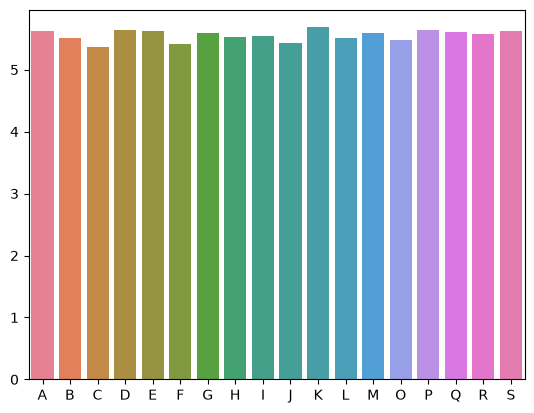

In [24]:
activity_percent = {}

for activity in ACTIVITIES.keys():
    activity_percent[activity] = (
        df[df["activity"] == activity].__len__() / df.__len__() * 100
    )

activity_percent = pd.DataFrame([activity_percent])

sns.barplot(activity_percent)

In [25]:
df

,subject_id,device,activity,timeStamp,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro
39263,1600,phone,A,1970-01-03 22:03:27.918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
39264,1600,phone,A,1970-01-03 22:03:27.968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
39265,1600,phone,A,1970-01-03 22:03:28.019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
39266,1600,phone,A,1970-01-03 22:03:28.069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
39267,1600,phone,A,1970-01-03 22:03:28.119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135
...,...,...,...,...,...,...,...,...,...,...
17989,1650,watch,S,1970-01-29 01:56:24.371437252,2.137723,-7.211485,8.065467,-2.856065,2.057101,0.853933
17990,1650,watch,S,1970-01-29 01:56:24.421424592,1.486500,-13.302334,5.355231,-2.911458,1.817417,1.281104
17991,1650,watch,S,1970-01-29 01:56:24.471411932,4.017171,-13.146711,5.118205,-3.015854,1.550036,2.057682
17992,1650,watch,S,1970-01-29 01:56:24.521399272,4.412214,-15.318253,3.370437,-3.218254,1.595842,3.018550


C:\Users\netinova\AppData\Local\Temp\ipykernel_23840\2444229645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


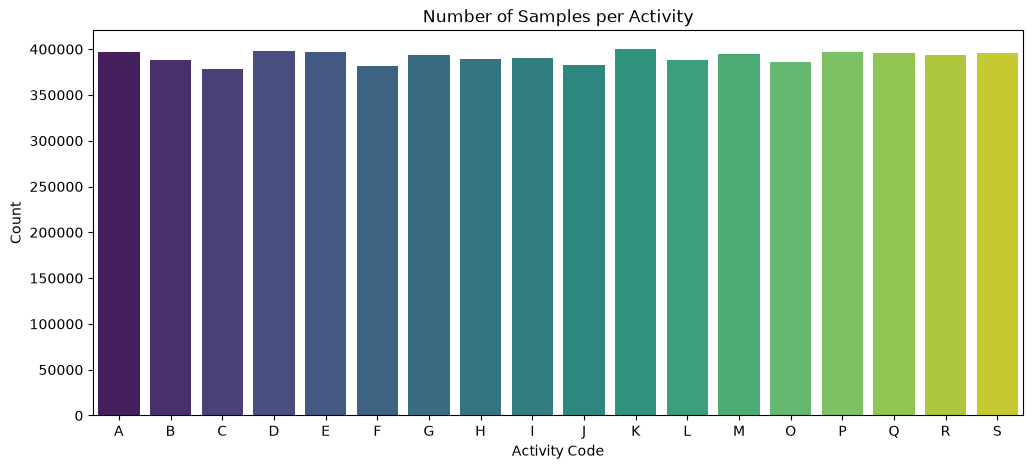

In [26]:
activity_counts = df["activity"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.barplot(
    x=activity_counts.index,
    y=activity_counts.values,
    palette="viridis",
)
plt.title("Number of Samples per Activity")
plt.xlabel("Activity Code")
plt.ylabel("Count")
plt.show()

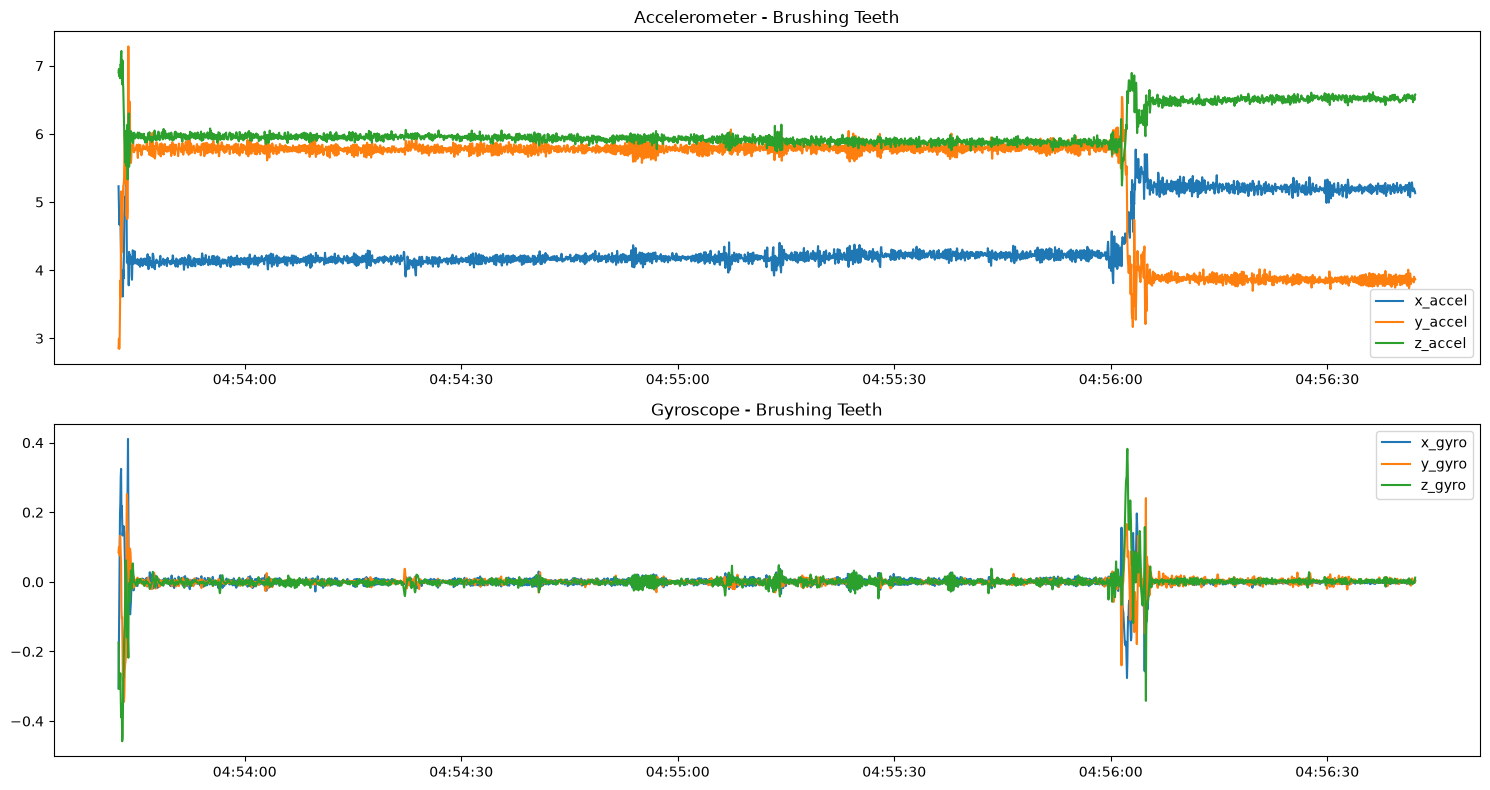

In [27]:
# Example: subject 1600, activity 'A' (Walking), phone

subj, act = 1604, "G"

sample = df[
    (df["subject_id"] == subj) & (df["activity"] == act) & (df["device"] == "phone")
]
sample = sample.sort_values("timeStamp")

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(sample["timeStamp"], sample["x_accel"], label="x_accel")
axes[0].plot(sample["timeStamp"], sample["y_accel"], label="y_accel")
axes[0].plot(sample["timeStamp"], sample["z_accel"], label="z_accel")
axes[0].set_title(f"Accelerometer - {ACTIVITIES[act]}")
axes[0].legend()

axes[1].plot(sample["timeStamp"], sample["x_gyro"], label="x_gyro")
axes[1].plot(sample["timeStamp"], sample["y_gyro"], label="y_gyro")
axes[1].plot(sample["timeStamp"], sample["z_gyro"], label="z_gyro")
axes[1].set_title(f"Gyroscope - {ACTIVITIES[act]}")
axes[1].legend()
plt.tight_layout()
plt.show()

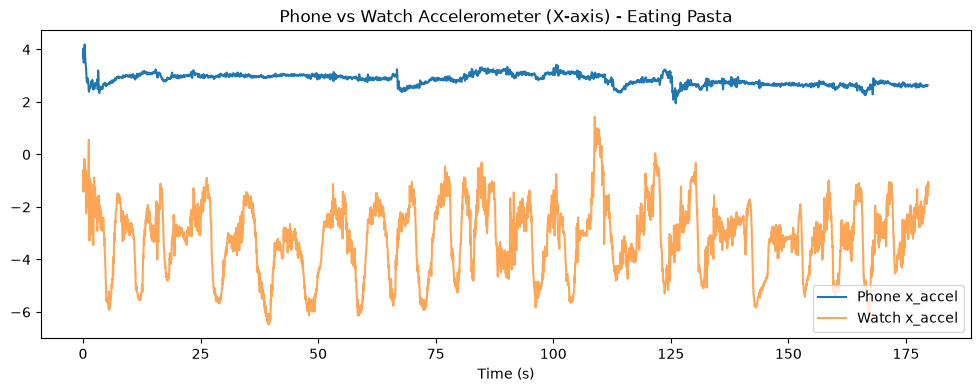

In [28]:
# Choose one subject and activity
subj, act = 1600, "J"
phone = df[
    (df["subject_id"] == subj) & (df["activity"] == act) & (df["device"] == "phone")
]
watch = df[
    (df["subject_id"] == subj) & (df["activity"] == act) & (df["device"] == "watch")
]

# Align by relative time
phone = phone.sort_values("timeStamp")
watch = watch.sort_values("timeStamp")


phone["rel_time"] = (phone["timeStamp"] - phone["timeStamp"].iloc[0]).dt.total_seconds()
watch["rel_time"] = (watch["timeStamp"] - watch["timeStamp"].iloc[0]).dt.total_seconds()

plt.figure(figsize=(12, 4))
plt.plot(phone["rel_time"], phone["x_accel"], label="Phone x_accel")
plt.plot(watch["rel_time"], watch["x_accel"], label="Watch x_accel", alpha=0.7)
plt.title(f"Phone vs Watch Accelerometer (X-axis) - {ACTIVITIES[act]}")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

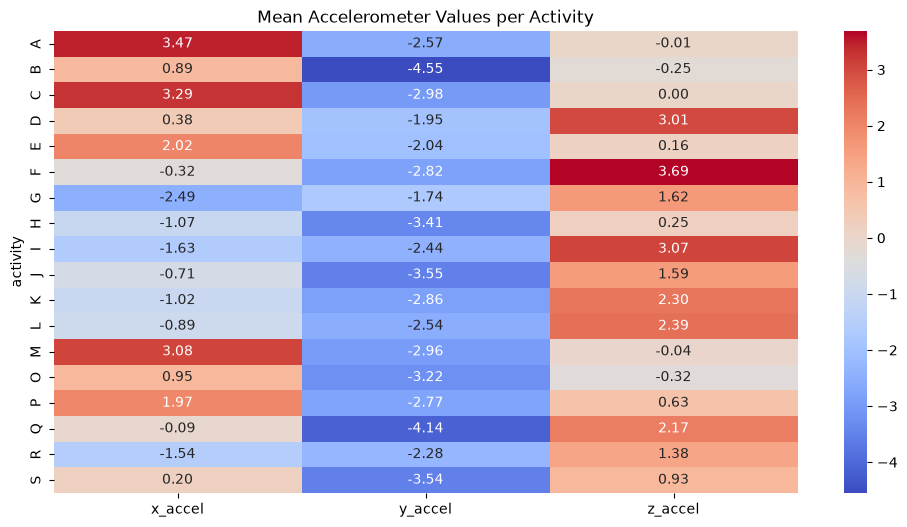

In [29]:
agg_stats = df.groupby("activity")[
    ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
].agg(["mean", "std"])


means = agg_stats.xs("mean", axis=1, level=1)
stds = agg_stats.xs("std", axis=1, level=1)

plt.figure(figsize=(12, 6))
sns.heatmap(
    means[["x_accel", "y_accel", "z_accel"]], annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Mean Accelerometer Values per Activity")
plt.show()

In [30]:
df = df.drop(columns="subject_id")

df

,device,activity,timeStamp,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro
39263,phone,A,1970-01-03 22:03:27.918580802,-4.332779,13.361191,-0.718872,-0.853210,0.297226,0.890182
39264,phone,A,1970-01-03 22:03:27.968934806,-0.319443,13.318359,-0.232025,-0.875137,0.015472,0.162231
39265,phone,A,1970-01-03 22:03:28.019288809,1.566452,9.515274,-0.017776,-0.720169,0.388489,-0.284012
39266,phone,A,1970-01-03 22:03:28.069642813,-0.323746,5.262665,0.322342,-0.571640,1.227402,-0.241669
39267,phone,A,1970-01-03 22:03:28.119996817,-1.811676,3.710510,1.373932,-0.380493,1.202835,-0.213135
...,...,...,...,...,...,...,...,...,...
17989,watch,S,1970-01-29 01:56:24.371437252,2.137723,-7.211485,8.065467,-2.856065,2.057101,0.853933
17990,watch,S,1970-01-29 01:56:24.421424592,1.486500,-13.302334,5.355231,-2.911458,1.817417,1.281104
17991,watch,S,1970-01-29 01:56:24.471411932,4.017171,-13.146711,5.118205,-3.015854,1.550036,2.057682
17992,watch,S,1970-01-29 01:56:24.521399272,4.412214,-15.318253,3.370437,-3.218254,1.595842,3.018550


In [31]:
df.sort_values(by=["device", "activity", "timeStamp"])

,device,activity,timeStamp,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro
32156,phone,A,1970-01-01 00:42:00.370204834,-0.042175,-9.739563,-1.787415,1.419601,0.155624,0.568573
32157,phone,A,1970-01-01 00:42:00.420558838,3.551483,-10.745132,-1.266403,0.659149,0.518616,0.614868
32158,phone,A,1970-01-01 00:42:00.470912842,4.413910,-9.672089,0.229324,0.025009,0.079651,0.379562
32159,phone,A,1970-01-01 00:42:00.521266846,3.762543,-13.238754,-0.679016,-0.753937,-0.570969,-0.193634
32160,phone,A,1970-01-01 00:42:00.571620850,-1.350037,-13.850220,-1.278030,-2.584717,-0.535828,-0.497726
...,...,...,...,...,...,...,...,...,...
18000,watch,S,1970-02-01 11:54:39.883261160,9.186103,-11.688044,-0.140959,2.565590,-0.616139,2.190737
18001,watch,S,1970-02-01 11:54:39.933204170,3.250877,-10.519673,-5.209484,3.962152,-0.677924,1.386463
18002,watch,S,1970-02-01 11:54:39.983147180,3.349039,-8.314613,-2.949357,3.070526,-1.091247,1.016816
18003,watch,S,1970-02-01 11:54:40.033090190,2.039411,-9.131037,-0.370802,-0.294645,-0.979394,1.029599


In [32]:
def extract_windows(df, window_sec=2):

    df = df.copy()

    df = df.sort_values(["device", "activity", "timeStamp"])
    df = df.set_index("timeStamp")

    sensor_cols = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]

    fs = 20.0

    def _extract_features(group):

        device, activity, window_start = group.name
        features = {
            "device": device,
            "activity": activity,
            "window_start": window_start,
        }

        for axis in sensor_cols:
            series = group[axis].values
            n = len(series)
            if n == 0:
                continue

            # Time domain features
            mean_val = np.mean(series)
            std_val = std_val = np.std(series, ddof=1) if n > 1 else np.nan
            p25 = np.percentile(series, 25)
            p75 = np.percentile(series, 75)
            kurt = pd.Series(series).kurtosis()
            autocorr = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 1 else np.nan
            rms = np.sqrt(np.mean(np.square(series)))

            # Frequency domain features
            if n > 1:
                fft_vals = np.fft.rfft(series)
                freqs = np.fft.rfftfreq(n, d=1 / fs)
                magnitudes = np.abs(fft_vals)

                if len(magnitudes) > 1:
                    idx_max = np.argmax(magnitudes[1:]) + 1
                    dom_freq = freqs[idx_max]
                    spectral_energy = np.sum(magnitudes[1:] ** 2)
                else:
                    dom_freq = 0.0
                    spectral_energy = 0.0
            else:
                dom_freq = 0.0
                spectral_energy = 0.0

            prefix = axis + "_"
            features[prefix + "mean"] = mean_val
            features[prefix + "std"] = std_val
            features[prefix + "p25"] = p25
            features[prefix + "p75"] = p75
            features[prefix + "kurt"] = kurt
            features[prefix + "autocorr"] = autocorr
            features[prefix + "rms"] = rms
            features[prefix + "dom_freq"] = dom_freq
            features[prefix + "spectral_energy"] = spectral_energy

        return pd.Series(features)

    grouped = df.groupby(["device", "activity", pd.Grouper(freq=f"{window_sec}s")])
    windows = grouped.apply(_extract_features).reset_index(drop=True)
    windows["window_start"] = pd.to_datetime(windows["window_start"])
    return windows

In [33]:
final_df = extract_windows(df)

c:\Users\netinova\Desktop\wisdm activity predictor\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3028: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\netinova\Desktop\wisdm activity predictor\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\netinova\Desktop\wisdm activity predictor\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\netinova\Desktop\wisdm activity predictor\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\netinova\Desktop\wisdm activity predictor\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [34]:
final_df

,device,activity,window_start,x_accel_mean,x_accel_std,x_accel_p25,x_accel_p75,x_accel_kurt,x_accel_autocorr,x_accel_rms,...,y_gyro_spectral_energy,z_gyro_mean,z_gyro_std,z_gyro_p25,z_gyro_p75,z_gyro_kurt,z_gyro_autocorr,z_gyro_rms,z_gyro_dom_freq,z_gyro_spectral_energy
0,phone,A,1970-01-01 00:42:00,0.870997,2.857928,-1.350037,3.762543,-1.399069,-0.120179,2.945994,...,1163.991032,-0.220454,0.660326,-0.737976,0.265854,-1.244075,0.851028,0.686598,1.212121,230.224043
1,phone,A,1970-01-01 00:42:02,0.735412,2.344767,-1.059269,2.166672,-0.297999,0.045216,2.429262,...,1058.900251,-0.108883,0.633125,-0.571301,0.398396,-0.635107,0.597237,0.634572,1.000000,314.260730
2,phone,A,1970-01-01 00:42:04,0.720333,2.820879,-1.549858,2.771217,-0.428853,-0.238528,2.876144,...,1132.695745,-0.042759,0.574698,-0.489609,0.361465,-0.625713,0.525619,0.568891,1.025641,244.735549
3,phone,A,1970-01-01 00:42:06,0.528281,2.024962,-1.146843,1.636425,-0.523692,0.171384,2.068100,...,1171.034601,-0.035543,0.523660,-0.347092,0.364979,-0.307843,0.741960,0.518293,1.000000,214.191224
4,phone,A,1970-01-01 00:42:08,0.566024,3.383486,-0.857811,2.496716,1.214016,-0.542687,3.388534,...,1388.430325,-0.070066,0.580034,-0.479481,0.352291,-0.607477,0.803165,0.577007,1.000000,265.059690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164174,watch,S,1970-02-01 11:54:32,3.599114,6.735197,-1.832612,9.433304,-0.526279,0.928162,7.561906,...,1754.013900,0.682539,1.363417,-0.100111,1.354773,4.389194,0.625977,1.509401,0.500000,1465.788839
164175,watch,S,1970-02-01 11:54:34,1.032410,5.853428,-4.917541,6.147861,-1.327483,0.963202,5.871279,...,1887.823359,-0.277451,0.765700,-0.739002,0.233052,-0.448318,0.834695,0.805368,1.500000,457.451217
164176,watch,S,1970-02-01 11:54:36,5.582530,3.884199,3.140145,7.216273,1.623699,0.362404,6.773069,...,1488.728465,-0.186131,1.512290,-0.330474,0.149426,3.265095,0.851293,1.504822,2.000000,1784.832351
164177,watch,S,1970-02-01 11:54:38,5.692185,3.719146,2.608034,9.086744,-0.947868,0.666856,6.774010,...,2663.507137,0.327458,1.430566,-0.488934,1.046644,0.965559,0.804004,1.450029,2.000000,1597.296046


In [ ]:
final_df = final_df.dropna()
final_df = final_df.drop(columns="window_start")

In [ ]:
df_phone = final_df[final_df["device"] == "phone"]
df_watch = final_df[final_df["device"] == "watch"]

df_phone = df_phone.drop(columns="device")
df_watch = df_watch.drop(columns="device")

In [ ]:
df_phone

In [ ]:
df_phone.skew(numeric_only=True)

In [8]:
def align_subject_sensors(subject_id):
    """
    Aligns all four sensors for one subject using per‑activity relative time.
    Returns a DataFrame with columns:
        activity, rel_time (timedelta),
        x_phone_accel, y_phone_accel, z_phone_accel,
        x_phone_gyro,  y_phone_gyro,  z_phone_gyro,
        x_watch_accel, y_watch_accel, z_watch_accel,
        x_watch_gyro,  y_watch_gyro,  z_watch_gyro.
    """

    TOLERANCE = pd.Timedelta("100ms")

    sensor_dfs = {}
    for device, sensor in SENSORS:
        filepath = (
            f"{RAW_DIR}/{device}/{sensor}/data_{subject_id}_{sensor}_{device}.txt"
        )
        df = get_sensor_data(filepath)

        df["rel_time"] = df.groupby("activity")["timeStamp"].transform(
            lambda x: (x - x.min())
        )

        suffix = f"{device}_{sensor}"
        df.rename(
            columns={
                "x": f"x_{suffix}",
                "y": f"y_{suffix}",
                "z": f"z_{suffix}",
            },
            inplace=True,
        )

        cols = [
            "activity",
            "rel_time",
            f"x_{suffix}",
            f"y_{suffix}",
            f"z_{suffix}",
        ]
        sensor_dfs[(device, sensor)] = df[cols]

    phone_accel = sensor_dfs[("phone", "accel")]
    phone_gyro = sensor_dfs[("phone", "gyro")]

    phone_merged_list = []

    for act, accel_grp in phone_accel.groupby("activity"):
        if act not in phone_gyro["activity"].values:
            continue

        gyro_grp = phone_gyro[phone_gyro["activity"] == act]

        # Sort by rel_time so merge_asof sees monotonic keys
        accel_grp = accel_grp.sort_values("rel_time")
        gyro_grp = gyro_grp.sort_values("rel_time")

        merged = pd.merge_asof(
            accel_grp if accel_grp.shape[0] < gyro_grp.shape[0] else gyro_grp,
            accel_grp if accel_grp.shape[0] >= gyro_grp.shape[0] else gyro_grp,
            on="rel_time",
            direction="nearest",
            tolerance=TOLERANCE,
        )

        merged.drop(columns=["activity_y"], inplace=True, errors="ignore")

        merged.rename(columns={"activity_x": "activity"}, inplace=True)

        phone_merged_list.append(merged)

    phone_merged = pd.concat(phone_merged_list, ignore_index=True)

    watch_accel = sensor_dfs[("watch", "accel")]
    watch_gyro = sensor_dfs[("watch", "gyro")]

    watch_merged_list = []
    for act, accel_grp in watch_accel.groupby("activity"):
        if act not in watch_gyro["activity"].values:
            continue
        gyro_grp = watch_gyro[watch_gyro["activity"] == act]

        accel_grp = accel_grp.sort_values("rel_time")
        gyro_grp = gyro_grp.sort_values("rel_time")

        merged = pd.merge_asof(
            accel_grp if accel_grp.shape[0] < gyro_grp.shape[0] else gyro_grp,
            accel_grp if accel_grp.shape[0] >= gyro_grp.shape[0] else gyro_grp,
            on="rel_time",
            direction="nearest",
            tolerance=TOLERANCE,
        )
        merged.drop(columns=["activity_y"], inplace=True, errors="ignore")
        merged.rename(columns={"activity_x": "activity"}, inplace=True)
        watch_merged_list.append(merged)

    watch_merged = pd.concat(watch_merged_list, ignore_index=True)

    final_list = []
    for act, phone_grp in phone_merged.groupby("activity"):
        if act not in watch_merged["activity"].values:
            continue
        watch_grp = watch_merged[watch_merged["activity"] == act]

        phone_grp = phone_grp.sort_values("rel_time")
        watch_grp = watch_grp.sort_values("rel_time")

        merged = pd.merge_asof(
            phone_grp if phone_grp.shape[0] < watch_grp.shape[0] else watch_grp,
            phone_grp if phone_grp.shape[0] >= watch_grp.shape[0] else watch_grp,
            on="rel_time",
            direction="nearest",
            tolerance=TOLERANCE,
        )
        merged.drop(columns=["activity_y"], inplace=True, errors="ignore")
        merged.rename(columns={"activity_x": "activity"}, inplace=True)
        final_list.append(merged)

    final = pd.concat(final_list, ignore_index=True)

    # Final clean‑up as in your version
    final.sort_values(["activity", "rel_time"], inplace=True)
    final.reset_index(drop=True, inplace=True)
    return final

In [9]:
df = align_subject_sensors(1600)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64247 entries, 0 to 64246
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   activity       64247 non-null  str            
 1   rel_time       64247 non-null  timedelta64[ns]
 2   x_phone_gyro   64247 non-null  float64        
 3   y_phone_gyro   64247 non-null  float64        
 4   z_phone_gyro   64247 non-null  float64        
 5   x_phone_accel  64247 non-null  float64        
 6   y_phone_accel  64247 non-null  float64        
 7   z_phone_accel  64247 non-null  float64        
 8   x_watch_gyro   64240 non-null  float64        
 9   y_watch_gyro   64240 non-null  float64        
 10  z_watch_gyro   64240 non-null  float64        
 11  x_watch_accel  64240 non-null  float64        
 12  y_watch_accel  64240 non-null  float64        
 13  z_watch_accel  64240 non-null  float64        
dtypes: float64(12), str(1), timedelta64[ns](1)
memory usage: 6.9 MB


In [10]:
def load_all_data_aligned():

    merged = pd.DataFrame()

    for subject_id in SUBJECTS:

        print(f"loading {subject_id} data...")

        if subject_id == SUBJECTS.start:
            merged = align_subject_sensors(subject_id)
            merged["subject_id"] = np.ones(merged.shape[0], dtype=int) * subject_id
            continue

        other = align_subject_sensors(subject_id)
        other["subject_id"] = np.ones(other.shape[0], dtype=int) * subject_id
        merged = pd.concat([merged, other])

    merged["subject_id"] = merged["subject_id"].astype("category")
    merged["activity"] = merged["activity"].astype("category")

    return merged

In [11]:
df = load_all_data_aligned().dropna()

loading 1600 data...
loading 1601 data...
loading 1602 data...
loading 1603 data...
loading 1604 data...
loading 1605 data...
loading 1606 data...
loading 1607 data...
loading 1608 data...
loading 1609 data...
loading 1610 data...
loading 1611 data...
loading 1612 data...
loading 1613 data...
loading 1614 data...
loading 1615 data...
loading 1616 data...
loading 1617 data...
loading 1618 data...
loading 1619 data...
loading 1620 data...
loading 1621 data...
loading 1622 data...
loading 1623 data...
loading 1624 data...
loading 1625 data...
loading 1626 data...
loading 1627 data...
loading 1628 data...
loading 1629 data...
loading 1630 data...
loading 1631 data...
loading 1632 data...
loading 1633 data...
loading 1634 data...
loading 1635 data...
loading 1636 data...
loading 1637 data...
loading 1638 data...
loading 1639 data...
loading 1640 data...
loading 1641 data...
loading 1642 data...
loading 1643 data...
loading 1644 data...
loading 1645 data...
loading 1646 data...
loading 1647 

In [33]:
res = df[(df["activity"] == "K") & (df["subject_id"] == 1600)].sort_values(by="rel_time").drop(columns=["activity"])

In [36]:
res.head(160).to_csv("../data/test/test_aligned(4s).csv", index=False)

In [24]:
res.head(160).to_csv("../data/test/test_aligned(4s).csv",index=False)

In [ ]:
def extract_windows_aligned(df, window_sec=2):

    df = df.copy()

    df = df.sort_values(["activity", "rel_time"])
    df = df.set_index("rel_time")

    sensor_cols = [
        "x_phone_accel",
        "y_phone_accel",
        "z_phone_accel",
        "x_phone_gyro",
        "y_phone_gyro",
        "z_phone_gyro",
        "x_watch_accel",
        "y_watch_accel",
        "z_watch_accel",
        "x_watch_gyro",
        "y_watch_gyro",
        "z_watch_gyro",
    ]

    fs = 20.0

    def _extract_features(group):

        _, activity, window_start = group.name

        features = {
            "activity": activity,
            "window_start": window_start,
        }

        for axis in sensor_cols:
            series = group[axis].values
            n = len(series)
            if n == 0:
                continue

            # Time domain features
            mean_val = np.mean(series)
            std_val = std_val = np.std(series, ddof=1) if n > 1 else np.nan
            p25 = np.percentile(series, 25)
            p75 = np.percentile(series, 75)
            kurt = pd.Series(series).kurtosis()
            autocorr = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 1 else np.nan
            rms = np.sqrt(np.mean(np.square(series)))

            # Frequency domain features
            if n > 1:
                fft_vals = np.fft.rfft(series)
                freqs = np.fft.rfftfreq(n, d=1 / fs)
                magnitudes = np.abs(fft_vals)

                if len(magnitudes) > 1:
                    idx_max = np.argmax(magnitudes[1:]) + 1
                    dom_freq = freqs[idx_max]
                    spectral_energy = np.sum(magnitudes[1:] ** 2)
                else:
                    dom_freq = 0.0
                    spectral_energy = 0.0
            else:
                dom_freq = 0.0
                spectral_energy = 0.0

            prefix = axis + "_"
            features[prefix + "mean"] = mean_val
            features[prefix + "std"] = std_val
            features[prefix + "p25"] = p25
            features[prefix + "p75"] = p75
            features[prefix + "kurt"] = kurt
            features[prefix + "autocorr"] = autocorr
            features[prefix + "rms"] = rms
            features[prefix + "dom_freq"] = dom_freq
            features[prefix + "spectral_energy"] = spectral_energy

        return pd.Series(features)

    grouped = df.groupby(
        by=["subject_id", "activity", pd.Grouper(freq=f"{window_sec}s")]
    )
    windows = grouped.apply(_extract_features).reset_index(drop=True)
    return windows

In [ ]:
final_df = extract_windows_aligned(df, window_sec=4)

In [16]:
final_df

,activity,window_start,x_phone_accel_mean,x_phone_accel_std,x_phone_accel_p25,x_phone_accel_p75,x_phone_accel_kurt,x_phone_accel_autocorr,x_phone_accel_rms,x_phone_accel_dom_freq,...,y_watch_gyro_spectral_energy,z_watch_gyro_mean,z_watch_gyro_std,z_watch_gyro_p25,z_watch_gyro_p75,z_watch_gyro_kurt,z_watch_gyro_autocorr,z_watch_gyro_rms,z_watch_gyro_dom_freq,z_watch_gyro_spectral_energy
0,A,0 days 00:00:00,-0.983394,1.871965,-2.242249,0.199303,0.298565,0.090896,2.104165,5.000000,...,5870.490183,-0.186391,3.649859,-2.569667,2.233872,-0.691271,0.932144,3.631762,1.000000,42110.807160
1,A,0 days 00:00:04,-1.250279,2.093961,-2.502457,0.103065,0.723889,0.032381,2.427420,5.063291,...,11442.173476,0.011671,4.195015,-3.711375,3.135613,-0.988316,0.923195,4.168396,1.012658,54219.901302
2,A,0 days 00:00:08,-1.451709,2.303164,-2.724995,0.168602,0.091544,0.135363,2.710298,5.000000,...,6894.924480,-0.076044,4.002029,-3.769968,3.198460,-0.998597,0.916977,3.977664,1.000000,50611.479412
3,A,0 days 00:00:12,-1.543645,2.382492,-2.804855,0.191849,0.458449,0.173311,2.826173,5.063291,...,8448.578810,0.182022,3.456222,-2.669023,2.579002,-0.939210,0.910633,3.439098,1.012658,36804.004834
4,A,0 days 00:00:16,-1.511405,2.084133,-2.424622,-0.051250,0.218431,0.204874,2.563915,5.000000,...,4919.338244,0.051435,3.335673,-3.031479,2.748114,-1.110942,0.926185,3.315159,1.000000,35162.779777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40528,S,0 days 00:02:40,-8.317125,0.619278,-8.785531,-7.973020,0.856606,0.651508,8.339861,0.250000,...,8551.056868,0.222951,1.210530,-0.296020,1.118385,-0.039005,0.762080,1.223426,1.000000,4631.648323
40529,S,0 days 00:02:44,-8.520432,0.534301,-8.856783,-8.168813,-0.118496,0.576136,8.536959,0.250000,...,6363.588743,-0.090251,0.965456,-0.814804,0.575366,0.280702,0.814467,0.963639,0.250000,2945.748414
40530,S,0 days 00:02:48,-8.022687,0.976119,-8.777148,-7.401210,-0.288018,0.810914,8.081114,0.500000,...,2888.411508,0.050284,1.466023,-0.795629,0.974308,0.644226,0.849276,1.457699,1.250000,6793.489549
40531,S,0 days 00:02:52,-8.645542,0.534180,-8.975336,-8.335267,0.044349,0.404281,8.661823,0.250000,...,7384.199609,0.249822,1.163238,-0.259801,0.836889,2.197982,0.711049,1.182632,2.750000,4276.391416


In [21]:
final_df.to_csv(
    "../data/processed/full_device&sensor_aligned_feature_extracted_data(4s).csv", index=False
)